# 04 · Integer Decisions — where linear gets hard

A linear program lets variables take any fractional value, and it solves fast to a
global optimum. But many real decisions are **whole numbers or yes/no**: take an
item or leave it, open a warehouse or do not. The moment a variable must be integer,
the problem becomes a **mixed-integer program (MILP)** — combinatorially harder,
because the solver can no longer just slide to a corner; it has to **search**
(branch-and-bound).

Two canonical examples: the **0/1 knapsack** and a small **facility-location**
problem. We will see why relaxing to fractions gives nonsense, and how the solver
returns the exact integer optimum — checked against brute force.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning, module="pulp")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from src.datasets.scenarios import knapsack_scenario, facility_scenario
from src.evaluation.optimum_check import brute_force_facility, brute_force_knapsack_scenario
from src.exporters import save_fig, save_json
from src.models import facility, knapsack
from src.solvers.backends import solve

ks = knapsack_scenario()
print("items :", ks.items)
print("value :", ks.value)
print("weight:", ks.weight)
print("budget:", ks.capacity)

items : ('a', 'b', 'c')
value : {'a': 60.0, 'b': 100.0, 'c': 120.0}
weight: {'a': 10.0, 'b': 20.0, 'c': 30.0}
budget: 50.0


## Relax to fractions and the answer is nonsense

Drop the 0/1 requirement and let the solver take *fractions* of items. It happily
packs **0.67 of an item** — meaningless if the item is a machine or a container.
The fractional optimum also *overshoots* the true integer value, because it is
solving an easier, looser problem.

In [2]:
milp = knapsack.build(ks)
relaxed = solve(milp.relaxation(), backend="scipy")

print("LP relaxation value:", round(relaxed.objective, 2))
for item in ks.items:
    print(f"  take {relaxed.values[item]:.3f} of item {item}")
fractional = [i for i in ks.items if abs(relaxed.values[i] - round(relaxed.values[i])) > 1e-6]
print("fractional (nonsensical) picks:", fractional)

LP relaxation value: 240.0
  take 1.000 of item a
  take 1.000 of item b
  take 0.667 of item c
fractional (nonsensical) picks: ['c']


## The integer optimum — found by search, checked by brute force

Require 0/1 and the solver branches until it proves the best whole-number packing.
On an instance this small we can also enumerate all `2^n` subsets by brute force and
confirm the solver is exactly right.

In [3]:
integer = solve(milp, backend="pulp")
bf = brute_force_knapsack_scenario(ks)

picked = [i for i in ks.items if integer.values[i] > 0.5]
print("integer optimum value:", round(integer.objective, 2))
print("items taken          :", picked)
print("brute-force optimum  :", bf)

assert abs(integer.objective - bf) < 1e-6
assert abs(integer.objective - ks.optimum) < 1e-6
print("verified: solver == brute force ==", ks.optimum)
print(f"relaxation {relaxed.objective:.0f} overshoots the integer optimum {integer.objective:.0f}")

integer optimum value: 220.0
items taken          : ['b', 'c']
brute-force optimum  : 220.0
verified: solver == brute force == 220.0
relaxation 240 overshoots the integer optimum 220


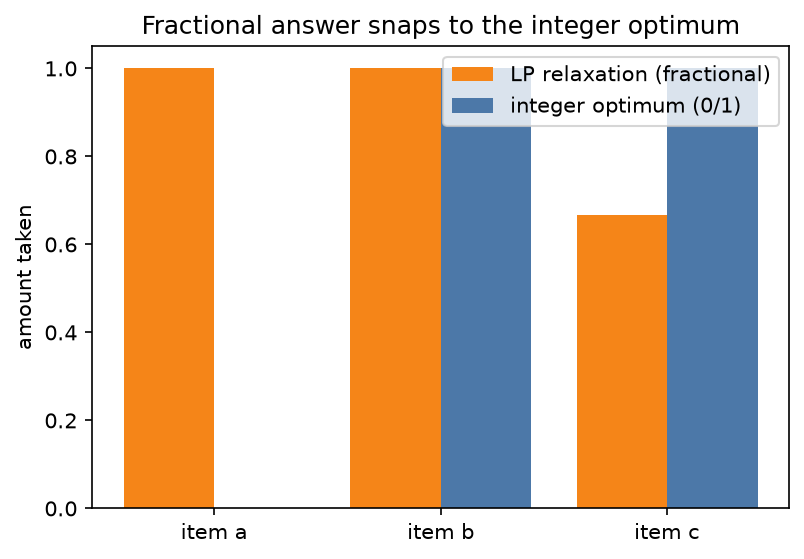

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(ks.items))
ax.bar(x - 0.2, [relaxed.values[i] for i in ks.items], width=0.4,
       label="LP relaxation (fractional)", color="#f58518")
ax.bar(x + 0.2, [round(integer.values[i]) for i in ks.items], width=0.4,
       label="integer optimum (0/1)", color="#4c78a8")
ax.set_xticks(x)
ax.set_xticklabels([f"item {i}" for i in ks.items])
ax.set_ylabel("amount taken")
ax.set_title("Fractional answer snaps to the integer optimum")
ax.legend()
path = save_fig(fig, "04_relaxation_vs_integer")
plt.close(fig)
Image(str(path))

## Binary decisions with a fixed cost: facility location

Open a depot and pay a fixed cost; then serve each customer from some **open** depot.
The open/closed choice is binary — half a warehouse is meaningless — and the
characteristic **linking constraint** `serve[c,d] <= open[d]` says you cannot serve a
customer from a depot you did not open. We enumerate every subset of depots to show
which one wins.

In [5]:
fac = facility_scenario()

# brute force: total cost for each non-empty subset of depots to open
candidate_costs = {}
from itertools import combinations
for r in range(1, len(fac.depots) + 1):
    for subset in combinations(fac.depots, r):
        fixed = sum(fac.open_cost[d] for d in subset)
        serving = sum(min(fac.serve_cost[c, d] for d in subset) for c in fac.customers)
        candidate_costs["+".join(subset)] = fixed + serving

sol = solve(facility.build(fac), backend="pulp")
bf_cost, bf_open = brute_force_facility(fac)
opened = tuple(d for d in fac.depots if sol.values[f"open_{d}"] > 0.5)

print("candidate total costs:", candidate_costs)
print("solver optimum       :", round(sol.objective, 2), "open:", opened)
print("brute-force optimum  :", bf_cost, "open:", bf_open)
assert abs(sol.objective - bf_cost) < 1e-6 and set(opened) == set(bf_open)
print("verified: open only", opened, "for total cost", round(sol.objective, 2))

candidate total costs: {'d0': 155.0, 'd1': 157.0, 'd0+d1': 245.0}
solver optimum       : 155.0 open: ('d0',)
brute-force optimum  : 155.0 open: ('d0',)
verified: open only ('d0',) for total cost 155.0


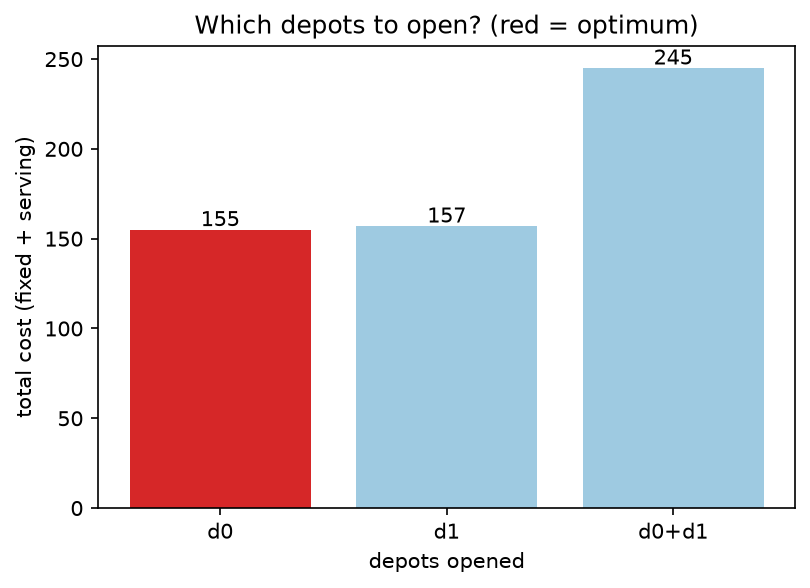

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = list(candidate_costs)
costs = [candidate_costs[k] for k in labels]
colors = ["#d62728" if abs(c - bf_cost) < 1e-6 else "#9ecae1" for c in costs]
ax.bar(labels, costs, color=colors)
ax.set_ylabel("total cost (fixed + serving)")
ax.set_xlabel("depots opened")
ax.set_title("Which depots to open? (red = optimum)")
for i, c in enumerate(costs):
    ax.text(i, c + 2, f"{c:.0f}", ha="center")
path = save_fig(fig, "04_facility_choice")
plt.close(fig)
Image(str(path))

In [7]:
save_json(
    {
        "knapsack": {
            "inputs": {"value": ks.value, "weight": ks.weight, "capacity": ks.capacity},
            "lp_relaxation": {
                "objective": relaxed.objective,
                "picks": {i: relaxed.values[i] for i in ks.items},
                "has_fractional_picks": bool(fractional),
            },
            "integer_optimum": {"objective": integer.objective, "items_taken": picked},
            "brute_force_optimum": bf,
            "relaxation_overshoots_integer": relaxed.objective > integer.objective,
            "solve_time_ms": {"relaxation": relaxed.solve_time * 1e3,
                              "integer": integer.solve_time * 1e3},
        },
        "facility": {
            "inputs": {
                "open_cost": fac.open_cost,
                "serve_cost": {f"{c}->{d}": v for (c, d), v in fac.serve_cost.items()},
            },
            "candidate_total_costs": candidate_costs,
            "integer_optimum": {"objective": sol.objective, "open_depots": list(opened)},
            "brute_force": {"cost": bf_cost, "open_depots": list(bf_open)},
        },
    },
    "04_integer_decisions",
)
print("saved 04_integer_decisions.json")

saved 04_integer_decisions.json


## The LP-versus-MILP line, made concrete

- **LP:** continuous, convex, global optimum, fast.
- **MILP:** integer/binary decisions, the solver must search, but on problems of this
  size branch-and-bound returns the exact optimum in milliseconds — and we proved it
  against brute force.

Relaxing integrality is a useful *bound* (it told us 240 was unreachable for the
knapsack) but not an *answer*. In **notebook 05** we collect the classic problem
shapes you will keep recognising.